# 03 — Results figures and tables

Reads the canonical retrieval JSON written by `02_retrieval.ipynb`
and produces the Results-section figures and tables:

| Output | Generator |
|---|---|
| Fig 5 — Annual-mean T(z) for published models | `make_letter_figures.fig_mean_T_profile` |
| Fig 6 — Per-site K_d sweep + bootstrap CIs | `make_letter_figures.fig_kd_sweep` |
| Fig 7 — Bootstrap distributions | `make_results_figures.fig_bootstrap` |
| Fig 8 — Annual-mean T(z) with per-site retrieved K_d* | `make_results_figures.fig_thermal_profiles` |
| Fig 9 — Diviner surface-T closure | `notebook cell` |
| Table 2 — Headline RMSE comparison | inlined below |
| Table 3 — Per-component error budget | inlined below |

Wall time: 5-10 min.

In [1]:
import sys, json, pathlib
ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts' / 'figures'))
OUTPUT = ROOT / 'output'
FIGS = ROOT / 'paper' / 'letter' / 'figures'

d = json.loads((OUTPUT / 'kd_retrieval_results.json').read_text())
# Helper: display a saved figure inline in this notebook.

from IPython.display import Image, display
import io
def show_fig(name):
    """Display a figure inline. Prefers the PNG companion; falls back to
    rendering the PDF on the fly via pymupdf if no PNG exists."""
    stem = name.replace('.pdf','').replace('.png','')
    png = FIGS / f"{stem}.png"
    if png.exists():
        display(Image(filename=str(png))); return
    pdf = FIGS / f"{stem}.pdf"
    if pdf.exists():
        try:
            import fitz
            pix = fitz.open(str(pdf))[0].get_pixmap(dpi=140)
            display(Image(data=pix.tobytes("png")))
        except Exception as e:
            print(f"  (couldn't render {pdf.name}: {e})")
    else:
        print(f"(no figure file for {stem})")


## Fig 5 — Annual-mean T(z) for the two published global models

Lunar-V2 notebook bootstrap
  python : /Library/Frameworks/Python.framework/Versions/3.13/bin/python3
  repo   : /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval


  deps   : all present
  lunar  : /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


Ensuring Apollo HFE (a17) ...


  → /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval/paper/letter/figures/fig_apollo_mean_T_profile.pdf


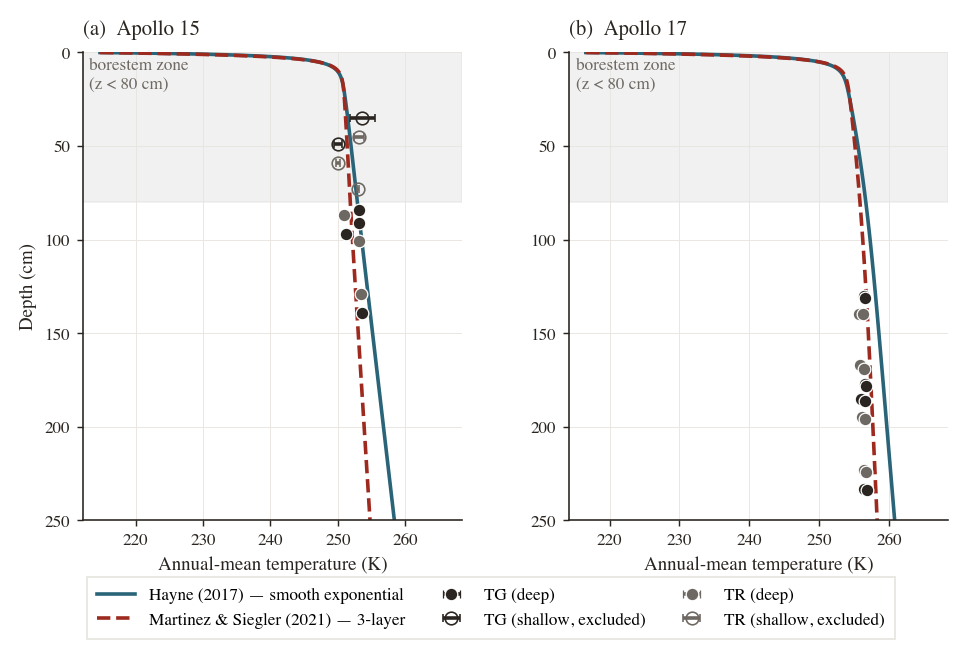

In [2]:
from make_letter_figures import fig_mean_T_profile
fig_mean_T_profile()
show_fig('fig_apollo_mean_T_profile')

## Fig 6 — Per-site K_d sweep

Lunar-V2 notebook bootstrap
  python : /Library/Frameworks/Python.framework/Versions/3.13/bin/python3
  repo   : /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval
  deps   : all present
  lunar  : /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


Ensuring Apollo HFE (a17) ...


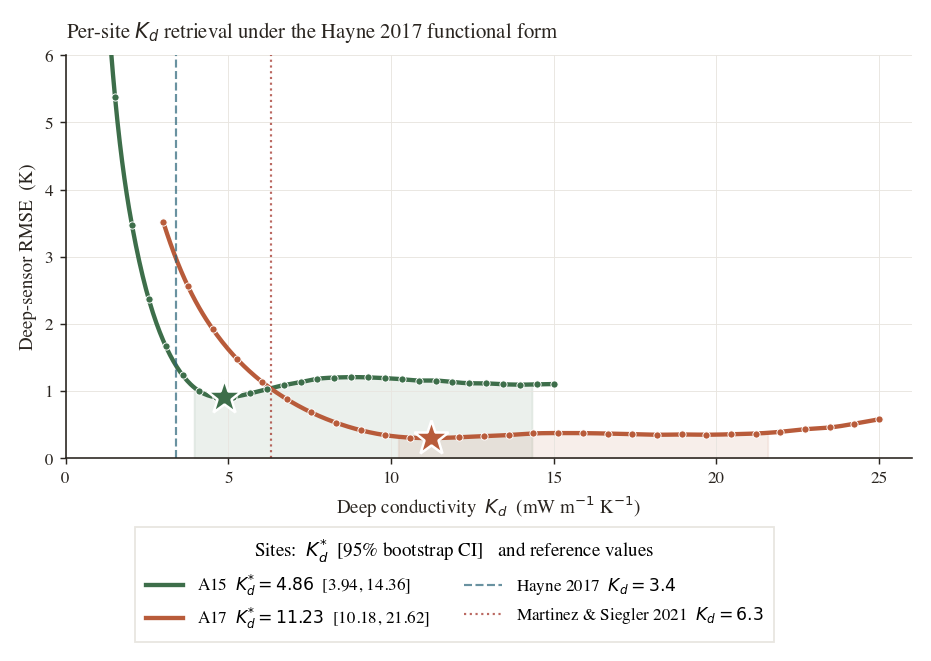

In [3]:
from make_letter_figures import fig_kd_sweep
fig_kd_sweep()
show_fig('fig_kd_sweep')

## Fig 7 — Bootstrap distributions

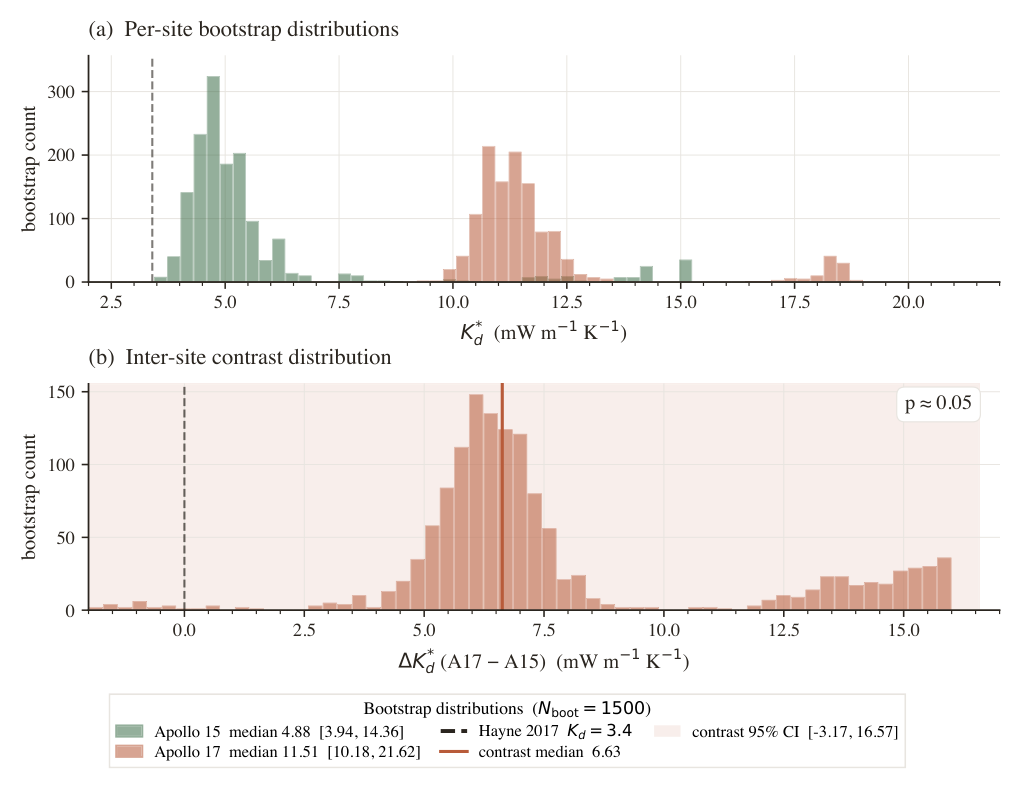

In [4]:
from make_results_figures import fig_bootstrap
fig_bootstrap(d, FIGS / 'fig_bootstrap.pdf')
show_fig('fig_bootstrap')

## Fig 8 — Annual-mean T(z) with per-site retrieved K_d*

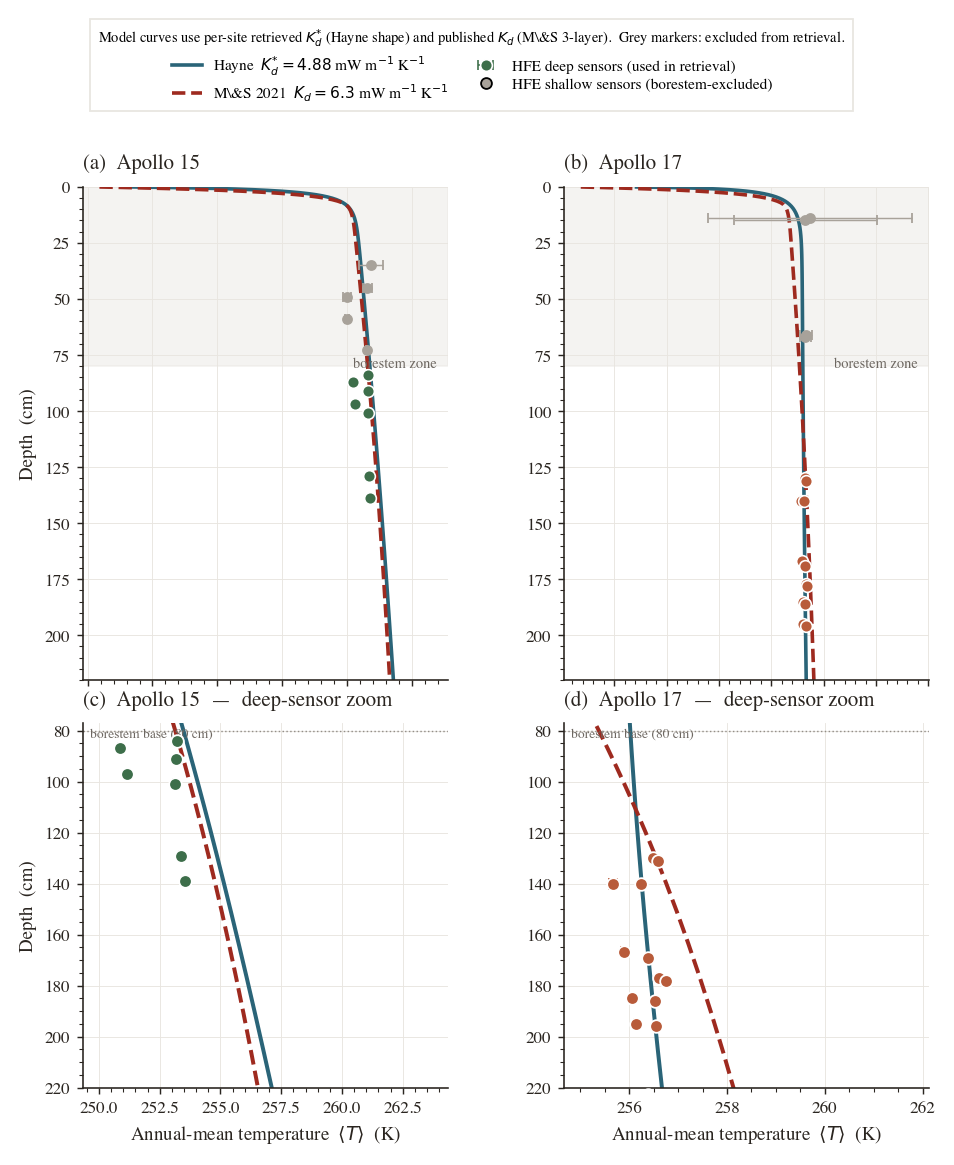

In [5]:
from make_results_figures import fig_thermal_profiles
fig_thermal_profiles(d, FIGS / 'fig_thermal_profiles.pdf')
show_fig('fig_thermal_profiles')

## Fig 9 — Diviner surface-T closure

Reads cached Diviner GCP tiles (fetch with `python scripts/fetch_diviner.py`
if missing). Runs the 1-D solver under both Hayne (per-site K_d*) and
Martinez (published coefficients) forward and compares to the GCP
diurnal composite.

In [ ]:
# Fig 9 -- Diviner surface-T closure (reproducible script).
# Requires the GCP tiles: python scripts/fetch_diviner.py  (~310 MB)
# Reads output/kd_retrieval_results.json (run 02_retrieval first).
# Writes output/diviner_closure.json and
# paper/letter/figures/fig_diviner_closure.pdf.
import subprocess, sys
subprocess.run([sys.executable, str(ROOT / 'scripts' / 'pipeline' /
                'compute_diviner_closure.py')], check=True)


## Table 2 — Headline RMSE comparison

In [7]:
import pandas as pd
t2 = json.loads((OUTPUT / 'headline_rmse.json').read_text())
rows = []
for site, sd in t2['sites'].items():
    n = sd['N_deep']
    rows.append((f'Apollo {site[-2:]}', 'Hayne (2017) global K_d',
                 f"{sd['hayne_global']['kd_mW']:.2f}", n,
                 f"{sd['hayne_global']['rmse_K']:.2f}"))
    rows.append((f'Apollo {site[-2:]}', 'Hayne, K_d* site fit',
                 f"{sd['hayne_site_fit']['kd_mW']:.2f}", n,
                 f"{sd['hayne_site_fit']['rmse_K']:.2f}"))
    rows.append((f'Apollo {site[-2:]}', 'Martinez (2021) forward',
                 '--', n,
                 f"{sd['martinez_forward']['rmse_K']:.2f}"))
pd.DataFrame(rows, columns=['Site','Model','K_d (mW/m/K)','N','RMSE (K)'])

,Site,Model,K_d (mW/m/K),N,RMSE (K)
0,Apollo 15,Hayne (2017) global K_d,3.40,7,1.37
1,Apollo 15,"Hayne, K_d* site fit",4.88,7,0.91
2,Apollo 15,Martinez (2021) forward,--,7,1.10
3,Apollo 17,Hayne (2017) global K_d,3.40,16,2.96
4,Apollo 17,"Hayne, K_d* site fit",11.23,16,0.30
5,Apollo 17,Martinez (2021) forward,--,16,2.46


## Table 3 — Per-component error budget

In [8]:
t3 = json.loads((OUTPUT / 'kd_error_budget.json').read_text())
# kd_error_budget shape: {'A15': {'sigma_stat':..., ...}, 'A17': {...}, ...}
rows = []
for site, sd in t3.items():
    if not isinstance(sd, dict): continue
    if any(k.startswith('sigma') for k in sd.keys()):
        row = {'Site': site}
        for k, v in sd.items():
            if isinstance(v, (int, float)):
                row[k] = f'{v:.2f}' if abs(v) > 0.05 else '<0.05'
        rows.append(row)
pd.DataFrame(rows) if rows else t3

,Site,sigma_stat,sigma_Qb,sigma_zb,sigma_thr,sigma_A,sigma_chi,sigma_H,sigma_Ks,sigma_rho,total_quadrature,median,ci95_lo,ci95_hi
0,A15,0.83,1.27,0.10,<0.05,0.56,0.73,0.26,0.10,<0.05,1.80,4.88,3.94,14.36
1,A17,4.44,3.00,3.81,0.06,0.95,1.73,1.39,0.23,0.06,7.00,11.51,10.18,21.62
